In [3]:
import pandas as pd
import matplotlib.pyplot as plt

mei_df = pd.read_csv("../data/processed/mei.csv")

rain_df = pd.read_csv("../data/processed/colombo_rainfall.csv")

print(mei_df.shape)
print(rain_df.shape)

(569, 2)
(312, 2)


In [4]:
mei_df["Date"] = pd.to_datetime(mei_df["Date"])

rain_df["Date"] = pd.to_datetime(rain_df["Date"])

print(mei_df.dtypes)
print(rain_df.dtypes)

Date    datetime64[us]
MEI            float64
dtype: object
Date        datetime64[us]
Rainfall           float64
dtype: object


In [5]:
merged_df = pd.merge(
    rain_df,
    mei_df,
    on="Date",
    how="inner"
)

print(merged_df.shape)

merged_df.head()

(312, 3)


,Date,Rainfall,MEI
0,2000-01-01,0.94,-1.25
1,2000-02-01,2.94,-1.26
2,2000-03-01,2.07,-1.37
3,2000-04-01,3.65,-0.90
4,2000-05-01,2.15,-0.94


In [6]:
merged_df[["Rainfall", "MEI"]].corr()

,Rainfall,MEI
Rainfall,1.000000,-0.035779
MEI,-0.035779,1.000000


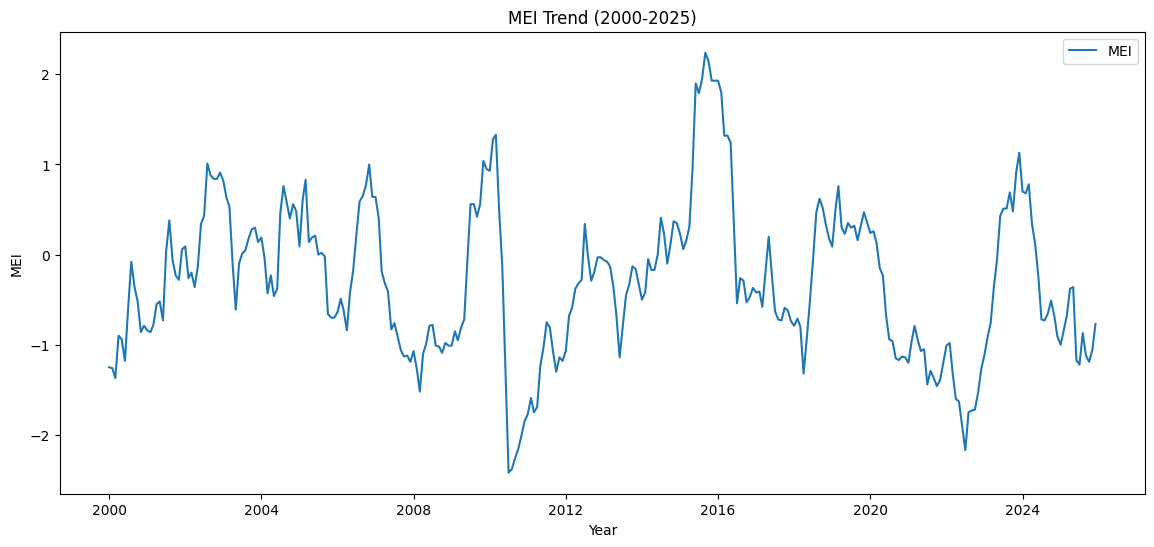

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    merged_df["Date"],
    merged_df["MEI"],
    label="MEI"
)

plt.title("MEI Trend (2000-2025)")
plt.xlabel("Year")
plt.ylabel("MEI")

plt.legend()

plt.show()

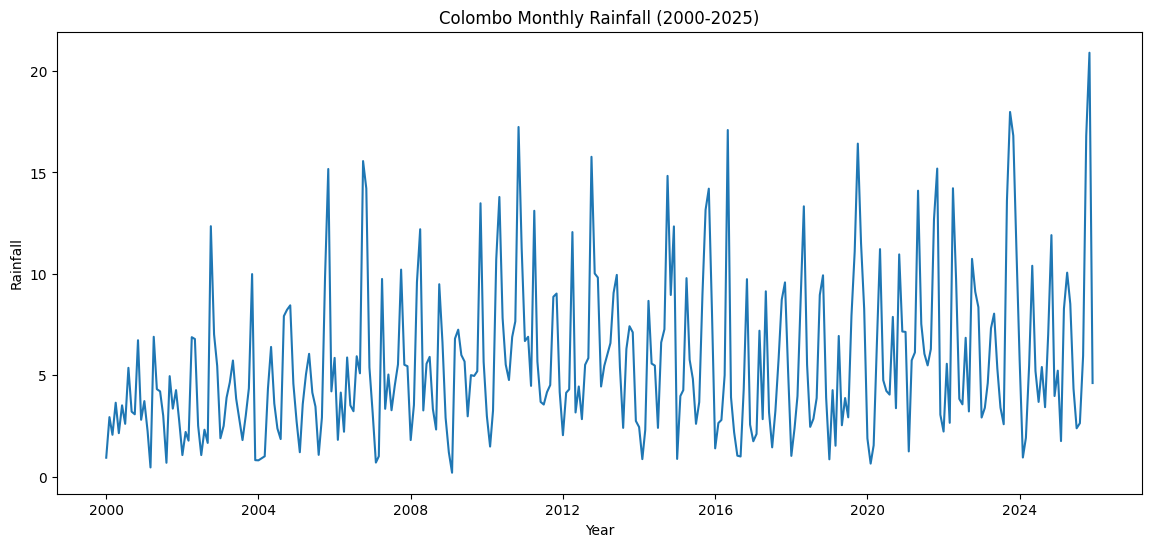

In [8]:
plt.figure(figsize=(14,6))

plt.plot(
    merged_df["Date"],
    merged_df["Rainfall"]
)

plt.title("Colombo Monthly Rainfall (2000-2025)")
plt.xlabel("Year")
plt.ylabel("Rainfall")

plt.show()

In [9]:
super_el_nino = merged_df[
    merged_df["MEI"] > 1.5
]

print(super_el_nino.shape)

super_el_nino.head(20)

(9, 3)


,Date,Rainfall,MEI
185,2015-06-01,4.82,1.90
186,2015-07-01,2.61,1.79
187,2015-08-01,3.68,1.95
188,2015-09-01,8.99,2.24
189,2015-10-01,13.16,2.15
190,2015-11-01,14.20,1.93
191,2015-12-01,8.19,1.93
192,2016-01-01,1.40,1.93
193,2016-02-01,2.65,1.80


In [10]:
def classify_enso(mei):

    if mei > 1.5:
        return "Super El Nino"

    elif mei > 0.5:
        return "El Nino"

    elif mei < -0.5:
        return "La Nina"

    else:
        return "Neutral"


merged_df["ENSO_Category"] = merged_df["MEI"].apply(
    classify_enso
)

merged_df.head()

,Date,Rainfall,MEI,ENSO_Category
0,2000-01-01,0.94,-1.25,La Nina
1,2000-02-01,2.94,-1.26,La Nina
2,2000-03-01,2.07,-1.37,La Nina
3,2000-04-01,3.65,-0.90,La Nina
4,2000-05-01,2.15,-0.94,La Nina


In [11]:
merged_df["ENSO_Category"].value_counts()

ENSO_Category
La Nina          137
Neutral          124
El Nino           42
Super El Nino      9
Name: count, dtype: int64

In [12]:
rainfall_by_category = (
    merged_df
    .groupby("ENSO_Category")["Rainfall"]
    .mean()
    .sort_values(ascending=False)
)

print(rainfall_by_category)

ENSO_Category
Super El Nino    6.633333
El Nino          5.973571
La Nina          5.937591
Neutral          5.253871
Name: Rainfall, dtype: float64


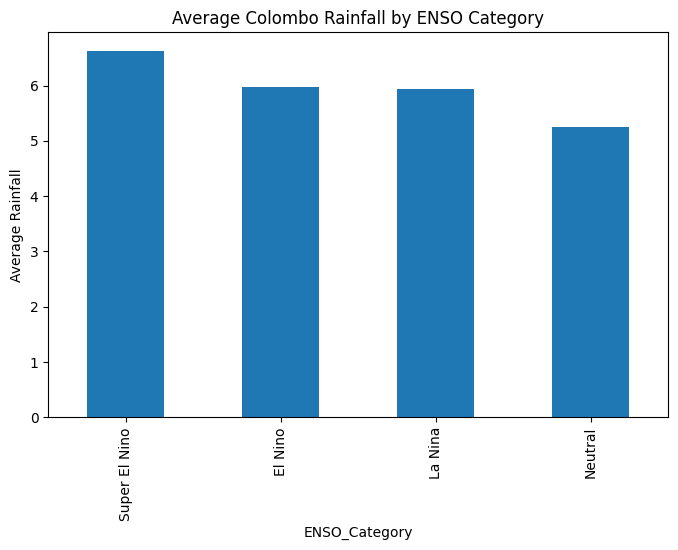

In [13]:
import matplotlib.pyplot as plt

rainfall_by_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Average Colombo Rainfall by ENSO Category"
)

plt.ylabel("Average Rainfall")

plt.show()

In [14]:
# Long-term average rainfall

overall_avg = merged_df["Rainfall"].mean()

print("Overall Average Rainfall:", round(overall_avg, 2))

Overall Average Rainfall: 5.69


In [15]:
merged_df["Rainfall_Anomaly"] = (
    merged_df["Rainfall"] - overall_avg
)

merged_df.head()

,Date,Rainfall,MEI,ENSO_Category,Rainfall_Anomaly
0,2000-01-01,0.94,-1.25,La Nina,-4.750769
1,2000-02-01,2.94,-1.26,La Nina,-2.750769
2,2000-03-01,2.07,-1.37,La Nina,-3.620769
3,2000-04-01,3.65,-0.90,La Nina,-2.040769
4,2000-05-01,2.15,-0.94,La Nina,-3.540769


In [16]:
anomaly_by_category = (
    merged_df
    .groupby("ENSO_Category")["Rainfall_Anomaly"]
    .mean()
    .sort_values(ascending=False)
)

print(anomaly_by_category)

ENSO_Category
Super El Nino    0.942564
El Nino          0.282802
La Nina          0.246822
Neutral         -0.436898
Name: Rainfall_Anomaly, dtype: float64


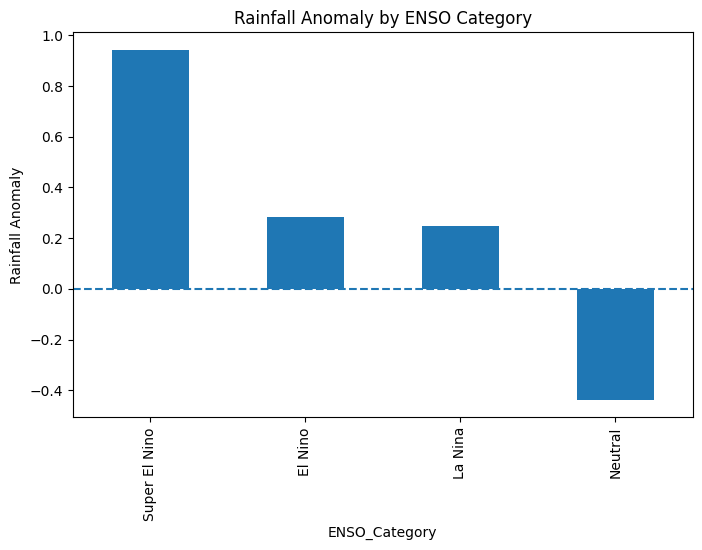

In [17]:
import matplotlib.pyplot as plt

anomaly_by_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title(
    "Rainfall Anomaly by ENSO Category"
)

plt.ylabel("Rainfall Anomaly")

plt.show()

In [18]:
merged_df["MEI_Lag_1"] = merged_df["MEI"].shift(1)

merged_df["MEI_Lag_3"] = merged_df["MEI"].shift(3)

merged_df["MEI_Lag_6"] = merged_df["MEI"].shift(6)

merged_df.head(10)

,Date,Rainfall,MEI,ENSO_Category,Rainfall_Anomaly,MEI_Lag_1,MEI_Lag_3,MEI_Lag_6
0,2000-01-01,0.94,-1.25,La Nina,-4.750769,NaN,NaN,NaN
1,2000-02-01,2.94,-1.26,La Nina,-2.750769,-1.25,NaN,NaN
2,2000-03-01,2.07,-1.37,La Nina,-3.620769,-1.26,NaN,NaN
3,2000-04-01,3.65,-0.90,La Nina,-2.040769,-1.37,-1.25,NaN
4,2000-05-01,2.15,-0.94,La Nina,-3.540769,-0.90,-1.26,NaN
5,2000-06-01,3.52,-1.18,La Nina,-2.170769,-0.94,-1.37,NaN
6,2000-07-01,2.61,-0.61,La Nina,-3.080769,-1.18,-0.90,-1.25
7,2000-08-01,5.37,-0.08,Neutral,-0.320769,-0.61,-0.94,-1.26
8,2000-09-01,3.21,-0.36,Neutral,-2.480769,-0.08,-1.18,-1.37
9,2000-10-01,3.08,-0.52,La Nina,-2.610769,-0.36,-0.61,-0.90


In [19]:
lag_df = merged_df.dropna().copy()

print(lag_df.shape)

lag_df.head()

(306, 8)


,Date,Rainfall,MEI,ENSO_Category,Rainfall_Anomaly,MEI_Lag_1,MEI_Lag_3,MEI_Lag_6
6,2000-07-01,2.61,-0.61,La Nina,-3.080769,-1.18,-0.90,-1.25
7,2000-08-01,5.37,-0.08,Neutral,-0.320769,-0.61,-0.94,-1.26
8,2000-09-01,3.21,-0.36,Neutral,-2.480769,-0.08,-1.18,-1.37
9,2000-10-01,3.08,-0.52,La Nina,-2.610769,-0.36,-0.61,-0.90
10,2000-11-01,6.73,-0.86,La Nina,1.039231,-0.52,-0.08,-0.94


In [20]:
correlations = lag_df[
    [
        "Rainfall",
        "MEI",
        "MEI_Lag_1",
        "MEI_Lag_3",
        "MEI_Lag_6"
    ]
].corr()

correlations

,Rainfall,MEI,MEI_Lag_1,MEI_Lag_3,MEI_Lag_6
Rainfall,1.000000,-0.053169,-0.043933,-0.023500,-0.070630
MEI,-0.053169,1.000000,0.939375,0.757875,0.458260
MEI_Lag_1,-0.043933,0.939375,1.000000,0.845264,0.553199
MEI_Lag_3,-0.023500,0.757875,0.845264,1.000000,0.758258
MEI_Lag_6,-0.070630,0.458260,0.553199,0.758258,1.000000


In [21]:
correlations["Rainfall"].sort_values(
    ascending=False
)

Rainfall     1.000000
MEI_Lag_3   -0.023500
MEI_Lag_1   -0.043933
MEI         -0.053169
MEI_Lag_6   -0.070630
Name: Rainfall, dtype: float64